c:\Users\cayez\Documents\DONNEES_SIMON\git\Workshop_nino



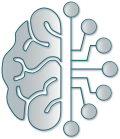

**Start at:** Monday 29 September 2025, 14:23:54  
**Hostname:** insa-09521 (Windows)

<p style="text-align: center"><img width="800px" src="./config/svg/pyPhysChemBanner.svg" style="margin-left:auto; margin-right:auto"/></p>

In [54]:
import os
import sys

print(os.getcwd())
cwd0 = './config/'
sys.path.append(cwd0)

import visualID_Eng as vID
from visualID_Eng import fg,bg,hl,color
vID.init(cwd0)

import tools4pyPhysChem as t4pPC

#cancel the "last show-up" behaviour of Jupyter notebooks
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

__author__ = "Simon Cayez, LPCNO / Département Génie Physique (INSA Toulouse, France)"

## Introduction to Image Processing in Python

## 1- Numpy Library basics

NumPy is a library designed for manipulating multidimensional arrays.  
It is an essential tool for data science and research. NumPy enables you to perform complex mathematical operations, data manipulations, and logical operations efficiently and with a clear syntax.  
It forms the foundation of many other scientific Python libraries.  
Because NumPy is written in C, it can handle complex operations on large amounts of data much faster than pure Python code.


### 1-1-  Dimension and shape

#### 1-1-1 Read dimension and shape

- **shape** returns a tuple indicating the size of the array along each dimension.  
- **ndim** returns the number of dimensions of the array.

In [55]:
import numpy as np

# --- 1D array ---
array_1d = np.array([1, 2, 3])
print("1D array:\n", array_1d)
print(f"  ndim  : {array_1d.ndim} (number of dimensions)")
print(f"  shape : {array_1d.shape} (size along each dimension)")
print("-" * 40)

# --- 2D array ---
array_2d = np.array([[1, 2, 3],
                     [4, 5, 6]])
print("2D array:\n", array_2d)
print(f"  ndim  : {array_2d.ndim}")
print(f"  shape : {array_2d.shape}")
print("-" * 40)

# --- 3D array ---
array_3d = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])
print("3D array:\n", array_3d)
print(f"  ndim  : {array_3d.ndim}")
print(f"  shape : {array_3d.shape}")


1D array:
 [1 2 3]
  ndim  : 1 (number of dimensions)
  shape : (3,) (size along each dimension)
----------------------------------------
2D array:
 [[1 2 3]
 [4 5 6]]
  ndim  : 2
  shape : (2, 3)
----------------------------------------
3D array:
 [[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
  ndim  : 3
  shape : (2, 2, 2)


#### 1-1-2- Change dimension and shape

We may sometimes need to change the shape of an array without altering its data, for example to use tools that expect NumPy arrays with specific dimensions as input.

In [56]:
import numpy as np

array_1 = np.array([1, 2, 3, 4, 5, 6])
array_2 = np.reshape(array_1, (2, 3))  # Request to reshape into 2 rows and 3 columns

print('Before:')
print(array_1)
print('Shape =', array_1.shape)
print('Number of dimensions =', array_1.ndim)
print('------------------')
print('After:')
print(array_2)
print('Shape =', array_2.shape)
print('Number of dimensions =', array_2.ndim)


Before:
[1 2 3 4 5 6]
Shape = (6,)
Number of dimensions = 1
------------------
After:
[[1 2 3]
 [4 5 6]]
Shape = (2, 3)
Number of dimensions = 2


- Flatten Array

**np.flatten** transforms a multi-dimensionnal into a single dimansion array

In [57]:
import numpy as np

# 3D array (2 blocs de 2×3)
my_array = np.array([
    [[1, 2, 3],
     [4, 5, 6]],
    [[7, 8, 9],
     [10, 11, 12]]
])

print('----- my_array -----')
print(my_array)
print('Shape of my_array:', my_array.shape)

# Flatten (convertir en tableau 1D)
my_flatten_array = my_array.flatten()

print('----- my_array (flattened) -----')
print(my_flatten_array)
print('Shape of flattened array:', my_flatten_array.shape)


----- my_array -----
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]
Shape of my_array: (2, 2, 3)
----- my_array (flattened) -----
[ 1  2  3  4  5  6  7  8  9 10 11 12]
Shape of flattened array: (12,)


- Squeeze a dimension

It often happens that one of the array’s dimensions is equal to 1 without it being necessary; to remove this or these dimensions, we can use `np.squeeze`.

In [58]:
# Create a 3D array with an unnecessary dimension of size 1
my_array = np.array([[[1], [2], [3]]])

print("Original array:")
print(my_array)
print("Shape of the array:", my_array.shape)   # (3,1,?) depending on how you build it
print("Number of dimensions:", my_array.ndim)
print('---------------')

# Automatically remove all dimensions of size 1
squeezed_array = np.squeeze(my_array)

print("Array after np.squeeze:")
print(squeezed_array)
print("Shape of the array:", squeezed_array.shape)  # Reduced dimensions
print("Number of dimensions:", squeezed_array.ndim)



Original array:
[[[1]
  [2]
  [3]]]
Shape of the array: (1, 3, 1)
Number of dimensions: 3
---------------
Array after np.squeeze:
[1 2 3]
Shape of the array: (3,)
Number of dimensions: 1


`np.squeeze()` removes all axes (dimensions) of size **1** from a NumPy array.  
This is useful when an array has redundant singleton dimensions and you want a simpler shape without altering the data itself.


### 1-2- Statistics on an array

NumPy allows you to perform various **statistical operations** on arrays, such as finding the **minimum**, **maximum**, or **mean** values. These operations can be applied to the whole array or along a specific axis.

By specifying the `axis` argument, you can choose the dimension along which the operation is performed:

- `axis=0` → operate **along columns** (down the rows)  
- `axis=1` → operate **along rows** (across columns)


In [59]:
import numpy as np

# Create a 2D array
arr = np.array([[1, 5, 3],
                [4, 2, 6]])

# Maximum of the entire array
print("Max of the whole array:", np.max(arr))

# Maximum of each column
print("Max of each column:", np.max(arr, axis=0))

# Maximum of each row
print("Max of each row:", np.max(arr, axis=1))

Max of the whole array: 6
Max of each column: [4 5 6]
Max of each row: [5 6]


### 1-3 Data Types in NumPy Arrays for Images

NumPy arrays can store data in various types. For **images**, the most common types are:

| Type        | Description                                    | Typical Use in Images                  |
|------------|-----------------------------------------------|---------------------------------------|
| `uint8`    | Unsigned 8-bit integer (0 to 255)             | Standard grayscale or RGB images      |
| `float32`  | 32-bit floating point                          | Normalized images (0.0 to 1.0)       |
| `float64`  | 64-bit floating point

In [60]:
# Example 1: Grayscale image with uint8 (0-255)
gray_image_uint8 = np.array([[0, 128, 255],
                             [64, 192, 32]], dtype=np.uint8)
print("Grayscale uint8 image:\n", gray_image_uint8)
print("dtype:", gray_image_uint8.dtype)

# Example 2: RGB image with uint8
rgb_image_uint8 = np.array([[[255, 0, 0], [0, 255, 0]],
                            [[0, 0, 255], [255, 255, 0]]], dtype=np.uint8)
print("\nRGB uint8 image:\n", rgb_image_uint8)
print("dtype:", rgb_image_uint8.dtype)

# Example 3: Normalized image with float32 (0.0 - 1.0)
normalized_image = np.array([[0.0, 0.5, 1.0],
                             [0.25, 0.75, 0.1]], dtype=np.float32)
print("\nNormalized float32 image:\n", normalized_image)
print("dtype:", normalized_image.dtype)

Grayscale uint8 image:
 [[  0 128 255]
 [ 64 192  32]]
dtype: uint8

RGB uint8 image:
 [[[255   0   0]
  [  0 255   0]]

 [[  0   0 255]
  [255 255   0]]]
dtype: uint8

Normalized float32 image:
 [[0.   0.5  1.  ]
 [0.25 0.75 0.1 ]]
dtype: float32


### 1-4- Select Parts of arrays

#### 1-3-1- Slice Notation

In NumPy, you can extract specific elements, rows, columns, or entire sub-arrays using **slicing**

In [61]:
# Define a 3D array (2 layers, 2 rows, 3 columns)
my_array = np.array([[[1, 2, 3], [4, 5, 6]],
                     [[7, 8, 9], [10, 11, 12]]])

print("Original 3D array (shape: {}):\n".format(my_array.shape), my_array)

# Access a single element: layer 0, row 1, column 2
print("\nmy_array[0, 1, 2] -> channel 0, row 1, column 2:")
print(my_array[0, 1, 2])

# Access all layers, row 0, all columns
print("\nmy_array[:, 0, :] -> all channelss, row 0, all columns:")
print(my_array[:, 0, :])

# Access all elements of the last layer
print("\nmy_array[-1, :, :] -> all rows and columns of the last channel:")
print(my_array[-1, :, :])

# Access all layers, all rows, only column 1
print("\nmy_array[:, :, 1:2] -> all channels, all rows, column 1 only (note the slice preserves dimensions):")
print(my_array[:, :, 1:2])

Original 3D array (shape: (2, 2, 3)):
 [[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]

my_array[0, 1, 2] -> channel 0, row 1, column 2:
6

my_array[:, 0, :] -> all channelss, row 0, all columns:
[[1 2 3]
 [7 8 9]]

my_array[-1, :, :] -> all rows and columns of the last channel:
[[ 7  8  9]
 [10 11 12]]

my_array[:, :, 1:2] -> all channels, all rows, column 1 only (note the slice preserves dimensions):
[[[ 2]
  [ 5]]

 [[ 8]
  [11]]]


#### 1-3-2- Conditional Selection

`np.where` returns the indices where a condition is true. It is commonly used to filter or replace values. The function returns a tuple, with each element being an array containing the indices of elements that satisfy the condition.

In [62]:
my_array = np.array([[0,8,6],[2,6,1]])
print("Original 3D array (shape: {}):\n".format(my_array.shape), my_array)
print(50*'*')
print(np.where(my_array> 3))

Original 3D array (shape: (2, 3)):
 [[0 8 6]
 [2 6 1]]
**************************************************
(array([0, 0, 1]), array([1, 2, 1]))


How to read this result:

`np.where` returns a tuple of arrays, one for each dimension of the input array.

The first array contains the row indices, and the second array contains the corresponding column indices.

So `(array([0, 0, 1]), array([1, 2, 1]))` means:

| Element | Row index | Column index | Value |
|---------|-----------|--------------|-------|
| 1       | 0         | 1            | 8     |
| 2       | 0         | 2            | 6     |
| 3       | 1         | 1            | 6     |


## 2- Images in numpy

Working with images in Python heavily relies on **NumPy**, an image can naturally be represented as a **NumPy array**:

NumPy provides:
- Efficient storage of pixel values (integer or float types).
- Fast mathematical and logical operations on all pixels at once (vectorization).
- Easy reshaping, slicing, masking, and statistical analysis.

Thanks to this, most image-processing libraries (OpenCV, scikit-image, PIL, etc.) internally use NumPy arrays for their data representation.  
So learning how to manipulate NumPy arrays is a **key step** for anyone who wants to process images in Python.

### 2-1 Build images from diffrent numpy arays shapes
#### 2-1-1- 1D numpy aray

In [63]:
my_image = np.random.randint(0, 256, size=(12, 12))
print(my_image)

[[247  41  72 230 103  78  41 179 158 206 173  88]
 [ 70   1 184 221 141 167 228 146 189 210  25 118]
 [164 241 136  39 250 216 199 178 237 214 217  14]
 [222  48  70  18  36  66 201  48  66  13  14  62]
 [250  38 223  55 135 111 139 104 169 239 177 160]
 [159  54 239   3 209 177  58 106 141  48   1 185]
 [ 34  85  11 249  79 206 135 137  40 127 148  38]
 [ 60  87 138 166 148  36 202 112  64 212 138 110]
 [ 99 226 100  36  98  99 142  82 242  70 162   2]
 [239 235  63 110 164  55  36  59 244 121 215  53]
 [ 67 199  23  24 188  78  91 132 181 157  42 166]
 [ 13  54  21  39  26 251  64 168 221  56 167 166]]


- Display image with matplotlib

`matplotlib.pyplot.imshow()` is a convenient function to **display NumPy arrays as images** directly inside a Jupyter Notebook.

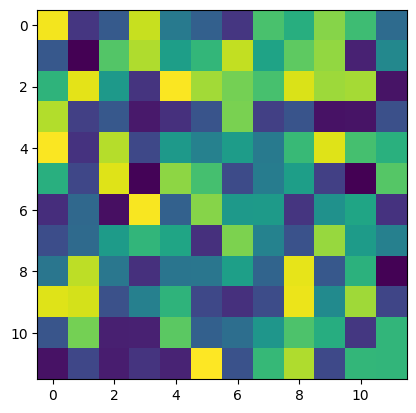

In [64]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots()
ax.imshow(my_image) 

The parameter `cmap` (short for **colormap**) controls **how pixel values are mapped to colors**.  
It determines the color scale used to represent the numerical data of an image.
#### Common Colormaps

| Colormap name | Description |
|---------------|-------------|
| `gray` / `Greys` | Black-to-white grayscale (default for many images) |
| `viridis` | Perceptually uniform, good for scientific data |
| `plasma` | Bright purple-to-yellow gradient |
| `inferno` | Dark purple-to-yellow gradient (high contrast) |
| `magma` | Dark purple-to-orange gradient |
| `jet` | Classic rainbow colormap (not recommended for quantitative data) |
| `hot` | Black-red-yellow-white gradient (heatmap style) |


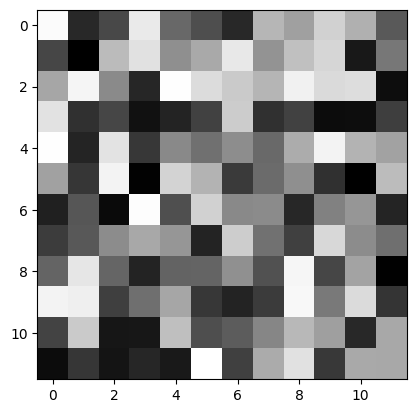

In [65]:
fig,ax = plt.subplots()
ax.imshow(my_image, cmap='gray')

#### 2-1-2- 2D numpy ara: 3 Channels

For color images, you usually have 3 channels:

- **R**: Red  
- **G**: Green  
- **B**: Blue  

Shape: (12, 12, 3)


(np.float64(-0.5), np.float64(11.5), np.float64(11.5), np.float64(-0.5))

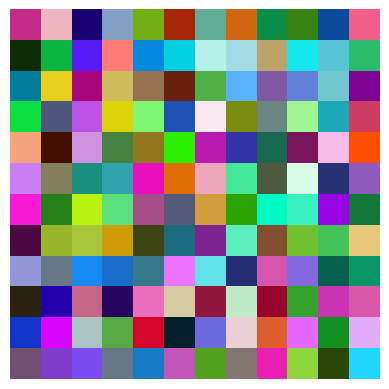

In [66]:
my_image_rgb = np.random.randint(0, 256, size=(12, 12, 3), dtype=np.uint8)
print("Shape:", my_image_rgb.shape)  
fig, ax = plt.subplots()
ax.imshow(my_image_rgb)
ax.axis('off')

#### 2-1-3- 2D numpy ara: 4 Channels

Sometimes a **4th channel** is added, called the **alpha channel**, which represents **transparency**.  
This is common in formats like **PNG**, where each pixel has RGBA values.


| Shape Example      | Meaning |
|-------------------|---------|
| `(height, width)` | Grayscale image (single channel) |
| `(height, width, 3)` | RGB image (3 channels: Red, Green, Blue) |
| `(height, width, 4)` | RGBA image (4 channels: Red, Green, Blue, Alpha = transparency) |


Shape: (12, 12, 3)


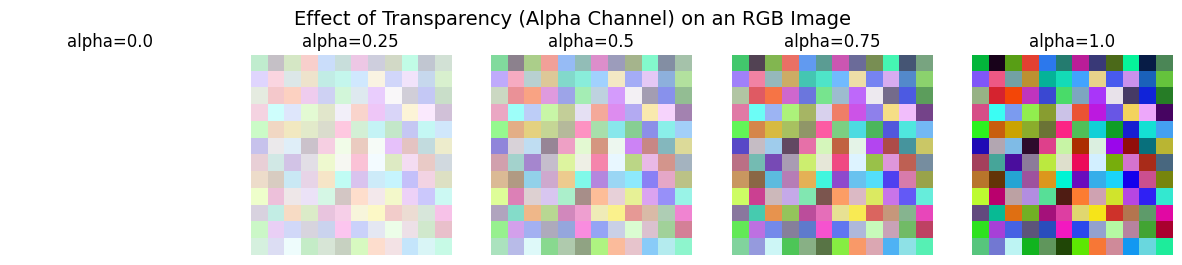

In [67]:
# Create a random 12x12 RGB image
my_image_rgb = np.random.randint(0, 256, size=(12, 12, 3), dtype=np.uint8)
print("Shape:", my_image_rgb.shape)

# Define alpha values to apply
alpha_values = [0.0, 0.25, 0.5, 0.75, 1.0]

# Create subplots: 1 row, 5 columns
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Loop over each alpha and display the image
for i, alpha in enumerate(alpha_values):
    axes[i].imshow(my_image_rgb, alpha=alpha)
    axes[i].axis('off')
    axes[i].set_title(f'alpha={alpha}')

fig.suptitle('Effect of Transparency (Alpha Channel) on an RGB Image', fontsize=14)
plt.show();



#### 2-1-4- 2D numpy arrays: Image stack

In addition to single images (2D for grayscale or 3D for RGB/RGBA),  
**NumPy arrays with 4 dimensions** can store **stacks of images**.  

This is common in:
- Deep learning datasets (batch of images)
- Time series of images (video frames)
- Multi-spectral imaging  

 We create a **stack of 6 random RGB images** with shape `(6, 12, 12, 3)`

Shape of image stack: (6, 12, 12, 3)


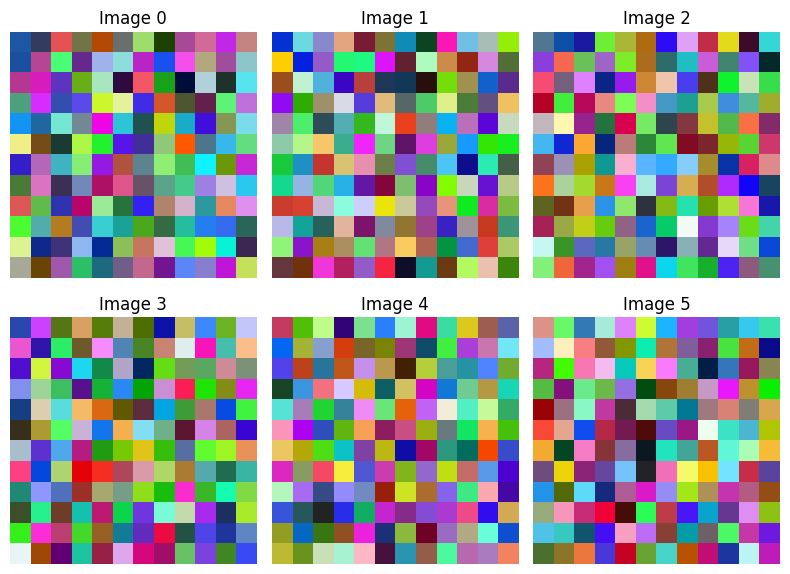

In [68]:
# Create a stack of 6 RGB images (12x12 pixels each)
image_stack = np.random.randint(0, 256, size=(6, 12, 12, 3), dtype=np.uint8)
print("Shape of image stack:", image_stack.shape)  # (6, 12, 12, 3)

# Plot each image in a 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(8, 6))
axes = axes.ravel()  # Flatten axes for easy iteration

for i in range(6):
    axes[i].imshow(image_stack[i])  # Show i-th image
    axes[i].set_title(f"Image {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show();


##### **Recap of NumPy array sizes for image data:**
| Shape Example        | Meaning |
|---------------------|---------|
| `(height, width)`   | Grayscale image (single channel, intensity only) |
| `(height, width, 3)` | RGB image (3 channels: Red, Green, Blue) |
| `(height, width, 4)` | RGBA image (4 channels: Red, Green, Blue, Alpha for transparency) |
| `(n_images, height, width)` | Stack of grayscale images (batch of images) |
| `(n_images, height, width, 3)` | Stack of RGB images |
| `(n_images, height, width, 4)` | Stack of RGBA images (with transparency) |

### 2-2- Open and save images
#### 2-2-1- Images with matplotlib

The function `matplotlib.pyplot.imread` reads an image from disk and returns it as a NumPy array.  
Each pixel is represented as numbers (for example, RGB values between 0 and 1 or 0 and 255 depending on the file type).  

(399, 847, 3)


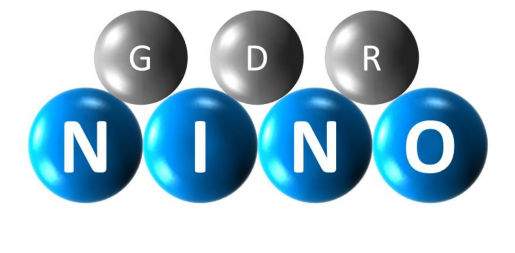

In [69]:
# Read image with matplotlib
#image = plt.imread('data/image1.jpg')
image = plt.imread('data/nino.jpg')
# Convert to numpy array
image = np.array(image)
print(image.shape)
fig,ax = plt.subplots()
ax.imshow(image)
ax.axis('off');

You can also **save images** back to disk using `matplotlib.pyplot.imsave`, which writes a NumPy array (image data) to a file in formats like PNG or JPEG.


In [70]:
# Create a random RGB image
my_image_rgb = np.random.randint(0, 256, size=(128, 128, 3), dtype=np.uint8)

# Save the image to disk as PNG
plt.imsave('data/my_image_rgb.png', my_image_rgb)

print("Image saved")


Image saved


Display multi channels image 

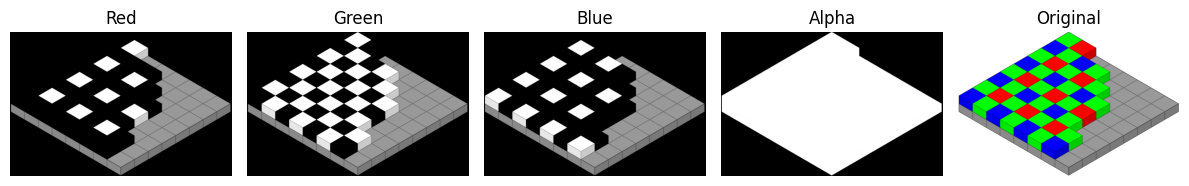

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# representing RGBA (Red, Green, Blue, Alpha) channels.
# Example (random RGBA image):
# image = np.random.randint(0, 256, size=(100, 100, 4), dtype=np.uint8)
image = plt.imread('data/rgb.png')
fig, axes = plt.subplots(1, 5, figsize=(12, 3))  # 1 row, 4 columns of subplots

channel_names = ['Red', 'Green', 'Blue', 'Alpha']

for i in range(4):
    # Show the i-th channel as a grayscale image
    axes[i].imshow(image[:, :, i], cmap='gray')
    axes[i].set_title(channel_names[i])  # Label the channel
    axes[i].axis('off')  # Remove axes for clarity

axes[4].imshow(image)
axes[4].set_title('Original')  # Label the channel
axes[4].axis('off')  # Remove axes for clarity


plt.tight_layout()
plt.show();


### 2-1 Python libraries for image

Python also offers several dedicated image-processing libraries.  
Each of them complements NumPy by adding higher-level functions for opening, manipulating, and saving images.


**Pillow (PIL)**  
Pillow is a friendly and easy-to-use library for opening, manipulating, and displaying images. It is often used for simple image processing tasks in scientific workflows.

**OpenCV (cv2)**  
OpenCV is a powerful library mainly used for computer vision tasks. It provides fast image display and processing capabilities, but note that `cv2.imshow` opens a separate window outside the notebook.

**scikit-image (skimage)**  
scikit-image is designed for scientific image processing. It integrates well with NumPy and Matplotlib, making it convenient for analysis and visualization of microscopy or experimental images.


open cv

In [85]:
import cv2
image  = cv2.imread('data/nino.jpg')
cv2.imshow("My Image", image)
cv2.waitKey(0) 
cv2.destroyAllWindows()

-1

Pil

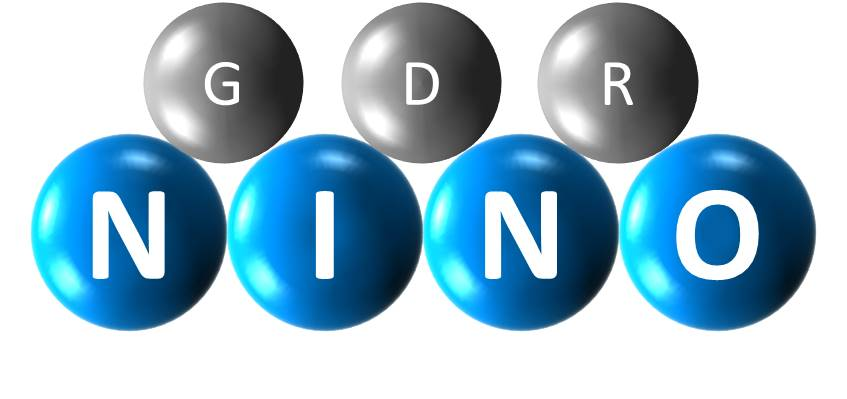

In [90]:
from PIL import Image
image = Image.open('data/nino.jpg')

#pil_img = Image.fromarray(image.astype(np.uint8))
display(image)  # affiche directement dans le notebook

Scikit image

C:\Users\cayez\AppData\Local\Temp\ipykernel_19980\3588165871.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(image)


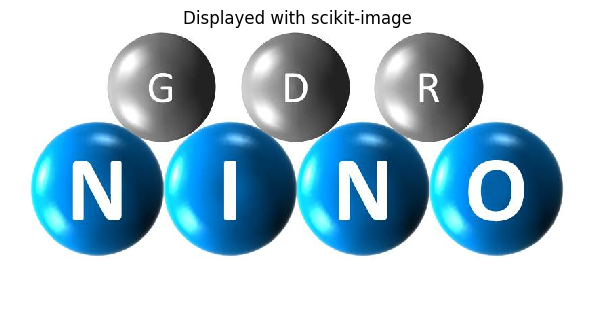

In [91]:
from skimage import io
image = io.imread('data/nino.jpg')
io.imshow(image)
plt.title("Displayed with scikit-image")
plt.axis('off')
plt.show();

Detection de contours

Shape: (1200, 1600, 3)
Dtype: uint8


(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

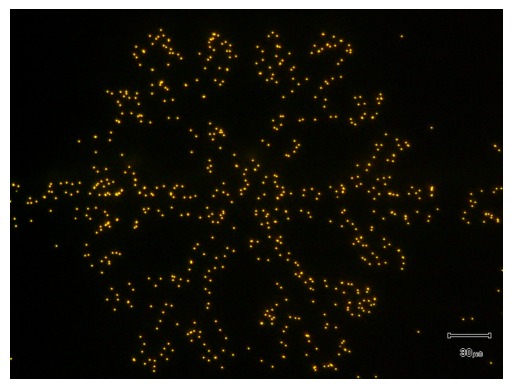

In [77]:

print("Shape:", image.shape)
print("Dtype:", image.dtype)
fig,ax = plt.subplots()
ax.imshow(image)
ax.axis('off')

Convertir l'image en niveaux de gris

Shape: (1200, 1600)


(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

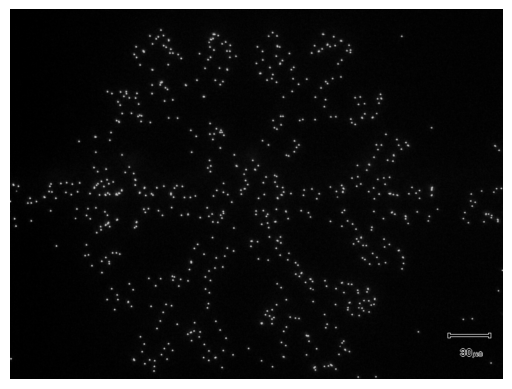

In [79]:
img_gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
print("Shape:", img_gray.shape)
fig,ax = plt.subplots()
ax.imshow(img_gray,cmap='gray')
ax.axis('off')

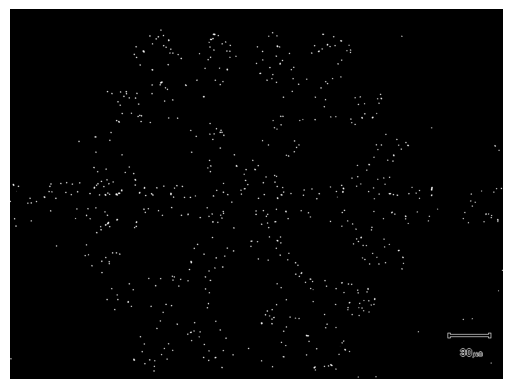

In [81]:
ret1,threshold=cv2.threshold(img_gray,140,255,cv2.THRESH_BINARY) 
fig,ax = plt.subplots()
ax.imshow(threshold,cmap='gray')
ax.axis('off');

In the backround, residuals blacks dots coming drom the carbon film. Need to filter the image before threshold.

In [ ]:
img_blur = cv2.blur(img_gray,(5,5)) 
fig,ax = plt.subplots()
ax.imshow(img_blur,cmap='gray')
ax.axis('off')

ret1,threshold=cv2.threshold(img_blur,140,255,cv2.THRESH_BINARY) 
fig,ax = plt.subplots()
ax.imshow(threshold,cmap='gray')
ax.axis('off')

Contours detections

Detect contours and plot contour #0

In [ ]:
contours, hierarchy = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(tem_image, [contours[0]], 0, (255, 0, 0), 2)
fig,ax = plt.subplots()
ax.imshow(tem_image)
ax.axis('off')

An all contours:

In [ ]:
contours, hierarchy = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for cnt in contours:
    cv2.drawContours(tem_image, [cnt], 0, (255, 0, 0), 1)

fig,ax = plt.subplots()
ax.imshow(tem_image)
ax.axis('off')

Display the id. of each contour

In [ ]:
for i, contour in enumerate(contours):
    x, y = contour[0][0] # determiner les coordonnées du premier point du contour
    #  Afficher le numéro du contour
    cv2.putText(tem_image, str(i), (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

fig,ax = plt.subplots()
ax.imshow(tem_image)
ax.axis('off')

Determine the index number of the scale bar in the image and extract the following features:  

The coordinates of the scale bar’s center (x, y)  
The width of the bounding box (in pixels or specified units)  
The height of the bounding box (in pixels or specified units)  
The rotation angle of the bounding box (in degrees)  

In [ ]:
#if needed plot R.O.I.
# Définir les coordonnées de la zone d'intérêt
x_start, x_end = 0, 200
y_start, y_end = 500, 600

# Extraire la région d'intérêt (ROI)
roi = tem_image[y_start:y_end, x_start:x_end]

fig,ax = plt.subplots()
ax.imshow(roi)
ax.axis('off')

# cv2.namedWindow("Region of Interest", cv2.WINDOW_NORMAL) # cv2.WINDOW_NORMAL pour fenetre étirable
# # Afficher la région d'intérêt
# cv2.imshow("Region of Interest", roi)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

In [ ]:
#Bounding box
# Obtenir le rectangle englobant orienté
rect = cv2.minAreaRect(contour)
box = cv2.boxPoints(rect)
box = np.round(box).astype(int)

In [ ]:
indice_echelle = 2
contour_echelle = contours[indice_echelle]


# Get the oriented bounding box
rect = cv2.minAreaRect(contour_echelle)
box = cv2.boxPoints(rect)
box = np.round(box).astype(int)


# Extract the coordinates, width, height, and angle of the bounding box
center, size, angle = rect
width, height = size

# Print values
print(f"Center coordinates: {center}")
print(f"Bounding box width: {width:.2f} pixels")
print(f"Bounding box height: {height:.2f} pixels")
print(f"Bounding box angle: {angle:.2f} degrees")


Read the length (visually or via OCR) and determine the ratio nm/pixel

In [ ]:
import easyocr
import matplotlib.pyplot as plt

# Charger le lecteur OCR (anglais ici, mais tu peux mettre ['fr'] pour français)
reader = easyocr.Reader(['en'])

# Fichier image avec texte (par exemple une image .tif contenant lettres/chiffres)
image_path = "images/tem.bmp"

# OCR
results = reader.readtext(image_path)

# Afficher l'image
img = plt.imread(image_path)
plt.imshow(img, cmap='gray')
plt.axis("off")

# Afficher le texte détecté
print("Detected text:")
for (bbox, text, prob) in results:
    print(f" {text} (confidence: {prob:.2f})")


In [ ]:
print(f"Text: {text}")

scale_nm = float(text.split()[0])# split with space and take first element
print(f"Scale nm: {scale_nm}") 

ratio = scale_nm/width
print(f"Ratio: {ratio}")

Manually create a list of indices to remove, in order to process only the particles and exclude the border, the scale bar, and the scale bar characters.

In [ ]:
index_to_remove = [0, 2, 8, 9, 10, 5, 6]

Create a function named "filtrer_contours" that takes as arguments:

- the list of contours to remove  
- the contours detected by cv2.findContours

and returns the selected contours after filtering.

In [ ]:
def filtrer_contours(indices_a_supprimer, contours):
    # Créer une liste de contours filtrée en utilisant une liste de compréhension
    contours_selection = [contour for i, contour in enumerate(contours) if i not in indices_a_supprimer]
    return contours_selection

 Reload the image'images/tem.bmp' and, using the "filtrer_contours" function, draw the contours and bounding boxes of the nanoparticles only.

In [ ]:
tem_image  = cv2.imread('images/tem.bmp')

#Utilisation de la fonction déterminée à la question 14
selected_contours = filtrer_contours(index_to_remove, contours)

# Afficher l'image avec les contours d'indices spécifiés
for cnt in selected_contours:
    cv2.drawContours(tem_image , [cnt], 0, (255, 0, 0), 1)
    
    # Obtenir le rectangle englobant orienté
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.round(box).astype(int)

    # Extraire les coordonnées, la largeur, la hauteur et l'angle du rectangle englobant
    center, size, angle = rect
    width, height = size

    # Dessiner le rectangle englobant orienté sur l'image
    cv2.drawContours(tem_image, [box], 0, (0, 0, 255), 2)  # Dessiner le rectangle en rouge

img = plt.imread(image_path)
plt.imshow(tem_image, cmap='gray')
plt.axis("off")


Observation:
When particles are touching, clusters are detected. To remove them, we will identify clusters using their convexity ratio.
Steps:

Measure the ratio between the area of the convex hull (calculated with cv2.convexHull(cnt)) and the area of the original contour.
Create a list of these convexity ratios.
Display the histogram of the convexity ratios.

In [ ]:
convexity_ratios = []
for cnt in selected_contours:
    # Calculer le polygone convexe
    hull = cv2.convexHull(cnt)

    # Calculer la surface du polygone convexe et la surface du contour d'origine
    area_hull = cv2.contourArea(hull)
    area_contour = cv2.contourArea(cnt)
    # Calculer le rapport de convexité
    convexity_ratio = area_contour / area_hull
        # Ajouter le rapport de convexité à la liste
    convexity_ratios.append(convexity_ratio)
    

# Tracer l'histogramme
plt.hist(convexity_ratios, bins=50, color='blue', edgecolor='black')
plt.title('Histogram of convexity ratios')
plt.xlabel('Convexity ratios')
plt.ylabel('Quantity of contours')
plt.show()

Check if there are values much lower than 1 in the convexity ratio list. These indicate concave (non-circular) objects.   
Filter them out by applying a condition with np.where and then use the filtrer_contours function to remove them.

In [ ]:
convexity_threshold = 0.92
# Utiliser np.where pour obtenir les indices inférieurs au seuil
index_above_threshold = np.where(np.array(convexity_ratios) < convexity_threshold )[0]

# Afficher les indices inférieurs à 0.92
print("Indices inférieurs  des objets de convexité inferieure à 0.92 :", index_above_threshold)
print("index of nano objects with convexity ration  :", index_above_threshold)


In [ ]:
selected_contours = filtrer_contours(index_above_threshold,selected_contours)

In [ ]:
convexity_ratios = []
for cnt in selected_contours:
    # Calculer le polygone convexe
    hull = cv2.convexHull(cnt)

    # Calculer la surface du polygone convexe et la surface du contour d'origine
    area_hull = cv2.contourArea(hull)
    area_contour = cv2.contourArea(cnt)
    # Calculer le rapport de convexité
    convexity_ratio = area_contour / area_hull
        # Ajouter le rapport de convexité à la liste
    convexity_ratios.append(convexity_ratio)
    

# Tracer l'histogramme
plt.hist(convexity_ratios, bins=50, color='blue', edgecolor='black')
plt.title('Histogramme des Rapports de Convexité')
plt.xlabel('Rapport de Convexité')
plt.ylabel('Nombre de Contours')
plt.show()

Verify visually that the clusters have been removed.

In [ ]:
tem_image  = cv2.imread('images/tem.bmp')
for cnt in selected_contours:
    cv2.drawContours(tem_image, [cnt], 0, (255, 0, 0), 1)
    
    # Obtenir le rectangle englobant orienté
    rect = cv2.minAreaRect(cnt)
    # rect = cv2.fitEllipse(cnt)
    box = cv2.boxPoints(rect)
    box = np.round(box).astype(int)

    # Extraire les coordonnées, la largeur, la hauteur et l'angle du rectangle englobant
    center, size, angle = rect
    width, height = size

    # Dessiner le rectangle englobant orienté sur l'image
    cv2.drawContours(tem_image, [box], 0, (0, 0, 255), 2)  # Dessiner le rectangle en rouge

# cv2.imshow("Contours select2", img)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
img = plt.imread(image_path)
plt.imshow(tem_image, cmap='gray')
plt.axis("off")


Extract the following values (in nm) for all contours:  

- Heights  
- Widths  
- Convexities  
- X positions  
- Y positions  
- Areas  
- Height-to-width ratios  
 
Store these results in a pandas DataFrame.

In [ ]:
# Create empty lists for values
contour_heights = []
contour_widths = []
contour_convexities = []
contour_x_positions = []
contour_y_positions = []
contour_areas = []
contour_perimeters = []
contour_height_width_ratios = []

# Loop on selected contours
for cnt in selected_contours:
    # Calculate values for each contour
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.round(box).astype(int)
    center, size, angle = rect
    width, height = size

    # Scale the results
    width_scaled = width * ratio
    height_scaled = height * ratio

    # Calculate area
    area = cv2.contourArea(cnt) * ratio * ratio

    # Calculate perimeter
    perimeter = cv2.arcLength(cnt, closed=True)
    perimeter_scaled = perimeter * ratio

    # Calculate convex hull
    hull = cv2.convexHull(cnt)

    # Calculate convexity ratio (contour area / convex hull area)
    convexity_ratio = area / (cv2.contourArea(hull) * ratio * ratio)

    # Calculate height/width ratio
    height_width_ratio = height_scaled / width_scaled

    # Append results to lists
    contour_heights.append(height_scaled)
    contour_widths.append(width_scaled)
    contour_convexities.append(convexity_ratio)
    contour_x_positions.append(center[0] * ratio)
    contour_y_positions.append(center[1] * ratio)
    contour_areas.append(area)
    contour_perimeters.append(perimeter_scaled)
    contour_height_width_ratios.append(height_width_ratio)


In [ ]:
import pandas as pd

# Create a pandas DataFrame with the results
data = {
    'Height (nm)': contour_heights,
    'Width (nm)': contour_widths,
    'Height/Width Ratio': contour_height_width_ratios,
    'Convexity': contour_convexities,
    'X Position (nm)': contour_x_positions,
    'Y Position (nm)': contour_y_positions,
    'Area (nm²)': contour_areas,
    'Perimeter (nm)': contour_perimeters
}

df = pd.DataFrame(data)
df.head()


Plot Histogram for each value

In [ ]:
df.hist(bins=20, figsize=(12,8), layout=(2, 4)) # bins représente le nombre de barres de l'histogramme
plt.show()

Fit a Gaussian distribution to the height and width values.

In [ ]:
from scipy.stats import norm
import numpy as np

# Nombre de barres pour l'histogramme
bins = 20

# Créer une figure avec des sous-graphiques
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Histogramme pour la hauteur
hist_height, bin_edges_height, _ = axes[0].hist(df['Height (nm)'], bins=bins, color='blue', edgecolor='black', density=True)
axes[0].set_title('Height (nm)')

# Ajuster une gaussienne aux données de hauteur
mu_height, std_height = norm.fit(df['Height (nm)'])
#definir les valeurs des x à partir de l'axe des abcisses de l'histogramme
xmin_height, xmax_height = axes[0].get_xlim()
x_height = np.linspace(xmin_height, xmax_height, 100)
p_height = norm.pdf(x_height, mu_height, std_height)
# tracer la gaussienne
axes[0].plot(x_height, p_height, 'k', linewidth=2)
title_height = "Ajustement gaussien :\n mu = %.2f,  std = %.2f" % (mu_height, std_height)
axes[0].set_title(title_height)

# Histogramme pour la largeur
hist_width, bin_edges_width, _ = axes[1].hist(df['Width (nm)'], bins=bins, color='green', edgecolor='black', density=True)
axes[1].set_title('Width (nm)')

# Ajuster une gaussienne aux données de largeur
mu_width, std_width = norm.fit(df['Width (nm)'])
xmin_width, xmax_width = axes[1].get_xlim()
x_width = np.linspace(xmin_width, xmax_width, 100)
p_width = norm.pdf(x_width, mu_width, std_width)
axes[1].plot(x_width, p_width, 'k', linewidth=2)
title_width = "Gaussian fit :\n mu = %.2f,  std = %.2f" % (mu_width, std_width)
axes[1].set_title(title_width)

# Afficher la figure
plt.show()
